# Time Series Super-Resolution

In this tutorial, we will go through how to perform time series super-resolution with `GenTS` models and datasets.

## Problem setting
Given a low-resolution time series $\mathbf{x}_{\text{lr}} \in \mathbb{R}^{(T / r) \times D}$, where $r$ is the super-resolution factor, we are interested in learning the conditional distribution $p(\mathbf{x}_{\text{hr}} \mid \mathbf{x}_{\text{lr}})$. From this distribution, we can sample possible high-resolution reconstructions $\hat{\mathbf{x}}_{\text{hr}} \in \mathbb{R}^{T \times D}$.

Two downsampling strategies are supported:
- **subsample**: take every $r$-th point from the original series
- **average**: average every $r$ consecutive points into one

## Implementation
### 1. Import modules

In [1]:
import torch
import matplotlib.pyplot as plt
from gents.dataset import Spiral2D
from gents.model import VanillaDDPM
from lightning import Trainer

/home/wcx/anaconda3/envs/gents/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
CUDA extension for cauchy multiplication not found. Install by going to extensions/cauchy/ and running `python setup.py install`. This should speed up end-to-end training by 10-50%
Falling back on slow Cauchy kernel. Install at least one of pykeops or the CUDA extension for efficiency.
Falling back on slow Vandermonde kernel. Install pykeops for improved memory efficiency.


### 2. Setup datamodule and model
Here, we set $T=64$, and the super-resolution factor $r=4$, so the low-resolution condition has length $64/4=16$.

Note that `condition='super_resolution'`, `sr_factor` and `sr_type` are required for both datamodule and model.

In [2]:
sr_factor = 4
sr_type = "subsample"  # or "average"

dm = Spiral2D(
    seq_len=64,
    batch_size=64,
    data_dir="../data",
    condition="super_resolution",
    sr_factor=sr_factor,
    sr_type=sr_type,
)
model = VanillaDDPM(
    seq_len=dm.seq_len,
    seq_dim=dm.seq_dim,
    condition="super_resolution",
    sr_factor=sr_factor,
    sr_type=sr_type,
)

### 3. Training
Utilizing `lightning`/`pytorch-lightning`, one can easily set GPU devices, training epochs, callbacks, etc.

In [3]:
trainer = Trainer(max_epochs=10, devices=[0], enable_progress_bar=False)
trainer.fit(model, dm)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3080 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name     | Type | Params | Mode 
------------------------------------------
0 | backbone | DiT  | 1.2 M  | train
------------------------------------------
1.2 M     Trainable params
1.0 K     Non-trainable params
1.2 M     Total params
4.703     Total estimated model params size (MB)
85        Modules in train mode
0         Modules in eval mode
`Trainer.fit` stopped: `max_epochs=10` reached.


### 4. Super-resolution on the test set
Here `n_sample=10` means we sample $\hat{\mathbf{x}}_{\text{hr}} \in \mathbb{R}^{T \times D}$ 10 times for each low-resolution input. The tensor shape of `gen_data` is `[batch_size, T, D, n_sample]`.

In [4]:
dm.setup("test")
real_data = torch.cat([batch["seq"] for batch in dm.test_dataloader()])
cond_data = torch.cat([batch["c"] for batch in dm.test_dataloader()])

gen_data = model.sample(
    n_sample=10,
    condition=cond_data,
)
print(f"Low-res condition shape: {cond_data.shape}")
print(f"Generated high-res shape: {gen_data.shape}")

Low-res condition shape: torch.Size([100, 16, 2])
Generated high-res shape: torch.Size([100, 64, 2, 10])


### 5. Visualization
We plot the ground truth high-resolution series and the super-resolution results (mean and 95% prediction interval).

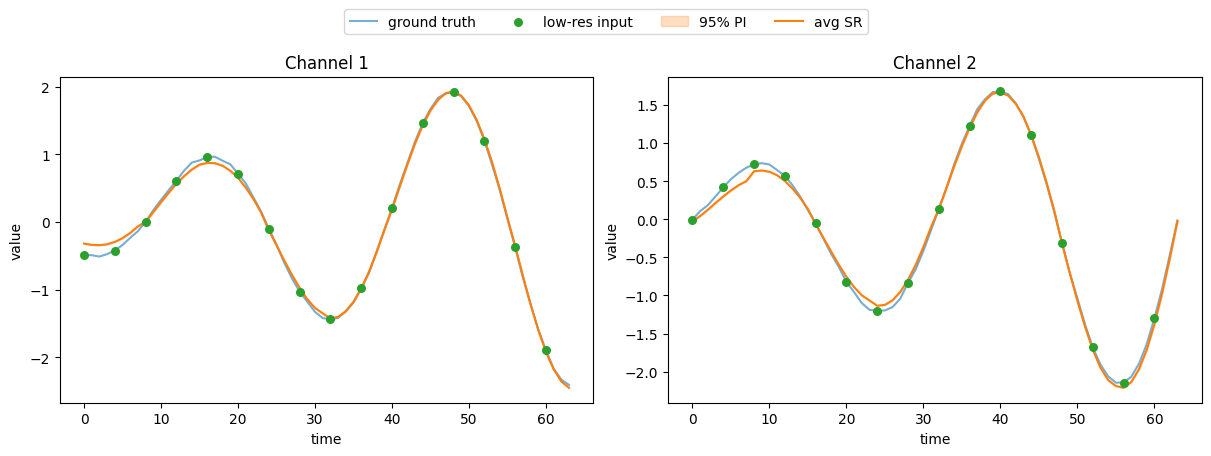

In [5]:
q = torch.tensor([0.05, 0.95])
gen_quantiles = torch.quantile(gen_data.cpu(), q, dim=-1)
gen_mean = gen_data.cpu().mean(dim=-1)

sample_id = torch.randint(0, len(real_data), ())
n_channel = min(3, real_data.shape[-1])
fig, axs = plt.subplots(1, n_channel, figsize=[12, 4], layout="constrained")
if n_channel == 1:
    axs = [axs]

t_hr = range(real_data.shape[1])
t_lr = range(0, real_data.shape[1], sr_factor)  # for subsample

for i in range(n_channel):
    ax = axs[i]
    # ground truth
    ax.plot(t_hr, real_data[sample_id, :, i].cpu(), c="C0", label="ground truth", alpha=0.6)
    # low-res condition
    ax.scatter(t_lr[:cond_data.shape[1]], cond_data[sample_id, :, i].cpu(),
               c="C2", zorder=5, s=30, label="low-res input")
    # super-resolution output
    ax.fill_between(t_hr, gen_quantiles[0, sample_id, :, i],
                    gen_quantiles[-1, sample_id, :, i],
                    color="C1", alpha=0.25, label="95% PI")
    ax.plot(t_hr, gen_mean[sample_id, :, i], c="C1", label="avg SR")
    ax.set_xlabel("time")
    ax.set_ylabel("value")
    ax.set_title(f"Channel {i + 1}")

fig.legend(*axs[0].get_legend_handles_labels(),
           loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.12))
plt.show()